# SWIGGY SALES ANALYSIS

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#

## Importing Data

In [2]:
df = pd.read_excel('/Users/vijayalaishmibalaji/Downloads/swiggy_data.xlsx')

#

## Metadata 

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [5]:
print("The Total No of Rows:",df.shape[0])
print("The Total No of Columns:",df.shape[1])

The Total No of Rows: 197430
The Total No of Columns: 10


#

## Data Type

In [6]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [7]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


#

## KPI

#### Total Sales

In [8]:
Total_Sales = df['Price (INR)'].sum()
Total_Sales_million = Total_Sales/100000

print(f'The toal Sales amount (INR): {round(Total_Sales_million,2)}M')

The toal Sales amount (INR): 530.13M


#### Average rating

In [9]:
Average_rating = df['Rating'].mean()

print(f'The Average Rating: {round(Average_rating,1)}')

The Average Rating: 4.3


#### Average Order Value

In [10]:
Average_order_value = Total_Sales/len(df)

print(f'The Average Order Value (INR): {round(Average_order_value,2)}')

The Average Order Value (INR): 268.51


#### Rating Count

In [11]:
Rating_count = df['Rating Count'].sum()
Rating_count_in_million = Rating_count/ 100000

print(f'The Ratings Count: {round(Rating_count_in_million,2)}M')

The Ratings Count: 55.92M


#### Total Orders

In [12]:
Total_Orders = len(df)


print(f'The Total No of Orders: {Total_Orders}')

The Total No of Orders: 197430


#

## Chart Design

#### Monthly sales Trend

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.strftime('%b')
df['year_month'] = df['Order Date'].dt.to_period('M').astype(str)

In [15]:
monthly_sales = df.groupby(df['year_month'])['Price (INR)'].sum().reset_index()
monthly_sales

,year_month,Price (INR)
0,2025-01,6825186.03
1,2025-02,6269105.67
2,2025-03,6573530.07
3,2025-04,6594515.00
4,2025-05,6793558.40
5,2025-06,6514183.19
6,2025-07,6650965.51
7,2025-08,6791461.90


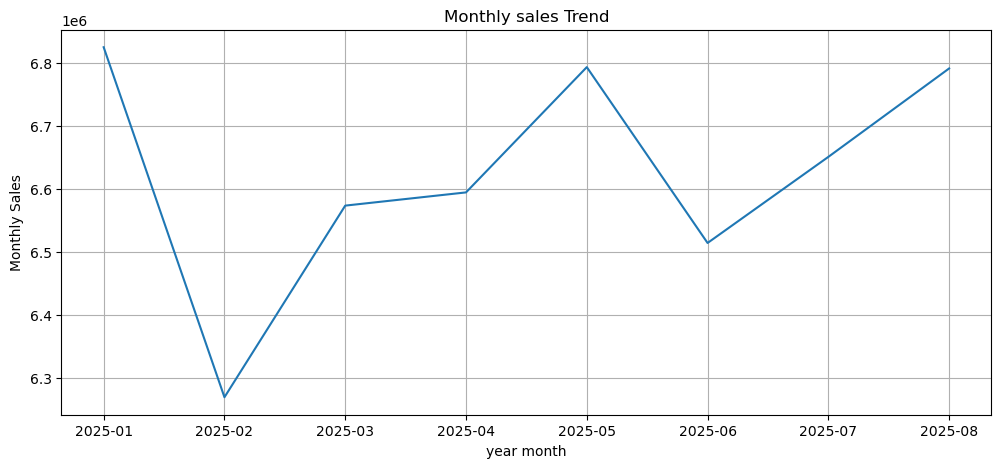

In [16]:
plt.figure(figsize=(12,5))
plt.figure
plt.plot(monthly_sales['year_month'],monthly_sales['Price (INR)'])
plt.xlabel("year month")
plt.ylabel("Monthly Sales")
plt.title("Monthly sales Trend")
plt.grid(True)
plt.tight_layout
plt.show()

#### Daily sales Trend

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order_day'] = df['Order Date'].dt.day_name()

In [18]:
Daily_sales_Trend = df.groupby(df['Order_day'])['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
Daily_sales_Trend

Order_day
Monday       7445437.01
Tuesday      7359414.01
Wednesday    7542103.06
Thursday     7664619.49
Friday       7579992.78
Saturday     7782935.40
Sunday       7638004.02
Name: Price (INR), dtype: float64

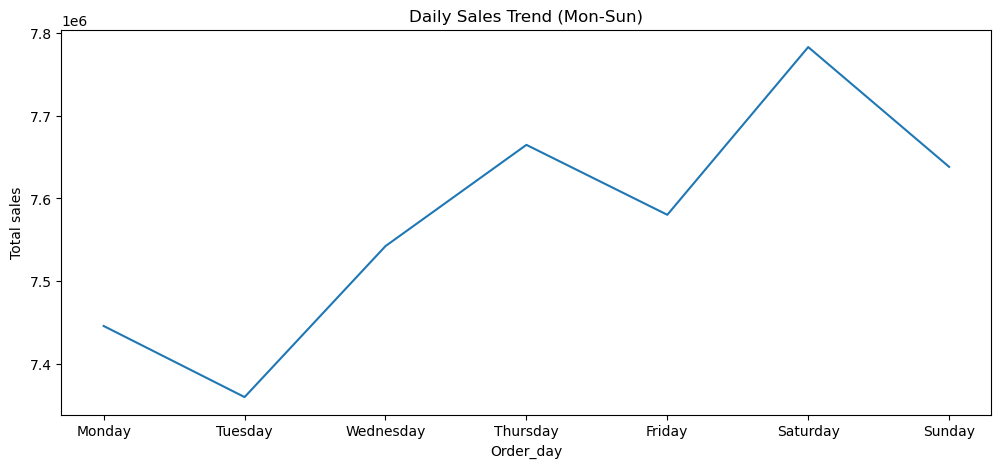

In [19]:
plt.figure(figsize=(12,5))
plt.plot(Daily_sales_Trend.index,Daily_sales_Trend.values)
plt.title('Daily Sales Trend (Mon-Sun)')
plt.xlabel('Order_day')
plt.ylabel('Total sales')
plt.show()

#### Total Sales by Food Type

In [20]:
df.groupby(df['Dish Name'])['Dish Name'].count().sort_values(ascending=False).head(10)

Dish Name
Choco Lava Cake         303
Veg Fried Rice          243
Chicken Sausage         227
Paneer Butter Masala    226
Jeera Rice              219
Margherita Pizza        199
French Fries            194
Butter Naan             186
Margherita              184
Veggie Supreme          179
Name: Dish Name, dtype: int64

In [21]:
nonveg_keyword = ['chicken','mutton','fish','egg','non veg','non-veg','non_veg','prawn','biriyani','kebab','kabab']

df['Food Category'] = np.where(df['Dish Name'].str.lower().str.contains("|".join(nonveg_keyword), na = False),"Non-veg","Veg")

In [22]:
sales_by_food_type = df.groupby(['Food Category'])['Price (INR)'].sum().reset_index()
sales_by_food_type

,Food Category,Price (INR)
0,Non-veg,18685424.72
1,Veg,34327081.05


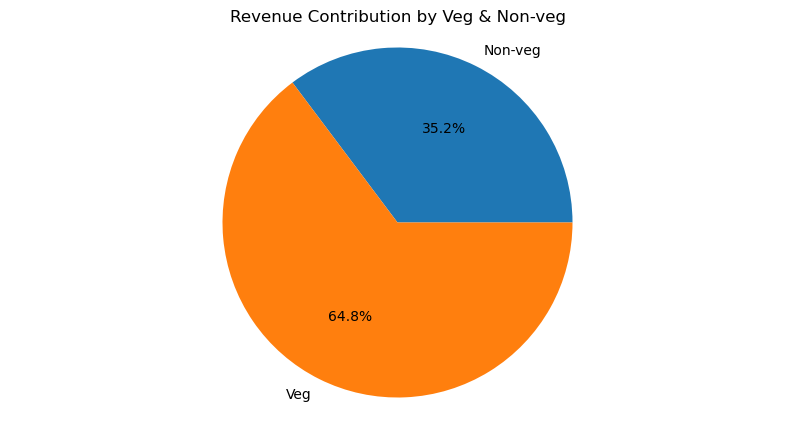

In [23]:
plt.figure(figsize =(10,5))
plt.pie(sales_by_food_type["Price (INR)"], labels = sales_by_food_type["Food Category"],autopct='%1.1f%%')
plt.title('Revenue Contribution by Veg & Non-veg')
plt.axis('equal')
plt.show()

#### Total Sales by State

In [24]:
sales_by_state = df.groupby(['State'])['Price (INR)'].sum().sort_values().reset_index()
sales_by_state 

,State,Price (INR)
0,Sikkim,560965.42
1,Nagaland,576797.60
2,Mizoram,824930.99
3,Tripura,1144272.46
4,Odisha,1193584.77
5,Jharkhand,1197037.32
6,Chhattisgarh,1226832.20
7,Bihar,1231696.87
8,Manipur,1254429.93
9,Assam,1259012.24


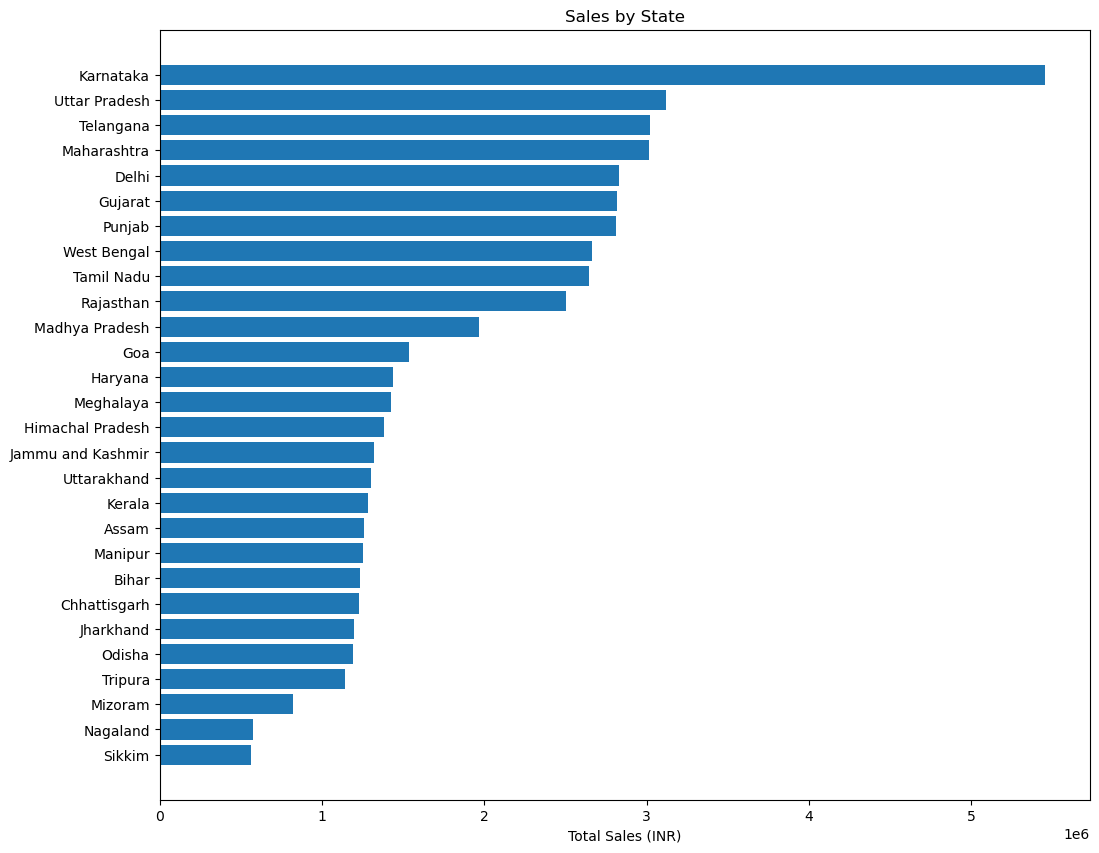

In [25]:
plt.figure(figsize = (12,10))
plt.barh(sales_by_state['State'], sales_by_state['Price (INR)'])
plt.xlabel('Total Sales (INR)')
plt.title('Sales by State')
plt.show()

#### Quarterly Performance Summary

In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

In [31]:
quarterly_summary = df.groupby("Quarter", as_index= False ).agg(Total_sales=("Price (INR)", "sum"),
                                                                Avg_Rating = ("Rating", "mean"),
                                                                Total_orders = ("Order Date", "count")).sort_values("Quarter")


In [33]:
quarterly_summary["Total_sales"] = quarterly_summary["Total_sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

In [34]:
quarterly_summary

,Quarter,Total_sales,Avg_Rating,Total_orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


#### Top 5 cities by Sales

In [3]:
top_5_cities = df.groupby("City")["Price (INR)"].sum().sort_values(ascending = False).head(5).reset_index()

top_5_cities 

,City,Price (INR)
0,Bengaluru,5456798.41
1,Lucknow,3117359.65
2,Hyderabad,3021711.62
3,Mumbai,3015573.35
4,New Delhi,2829180.60


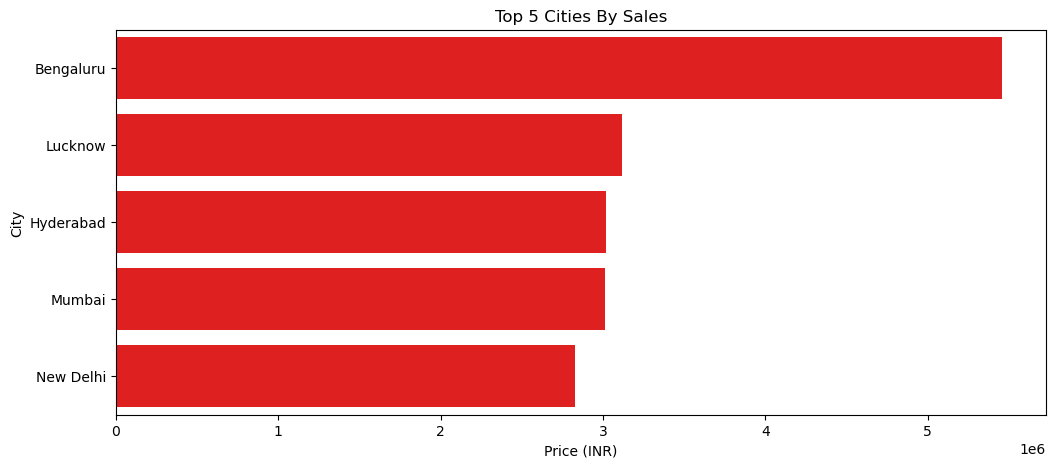

In [18]:
plt.figure(figsize=(12,5))

fig = sns.barplot(top_5_cities,
                  x = "Price (INR)",
                  y = "City",
                  color="red")

plt.title('Top 5 Cities By Sales')
plt.show()

#### Weekly Trend Analysis

In [35]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Day Name"] = df["Order Date"].dt.day_name()

In [40]:
Weekly_sales = df.groupby("Day Name")["Price (INR)"].sum().sort_values(ascending = False).reset_index()

Weekly_sales

,Day Name,Price (INR)
0,Saturday,7782935.40
1,Thursday,7664619.49
2,Sunday,7638004.02
3,Friday,7579992.78
4,Wednesday,7542103.06
5,Monday,7445437.01
6,Tuesday,7359414.01


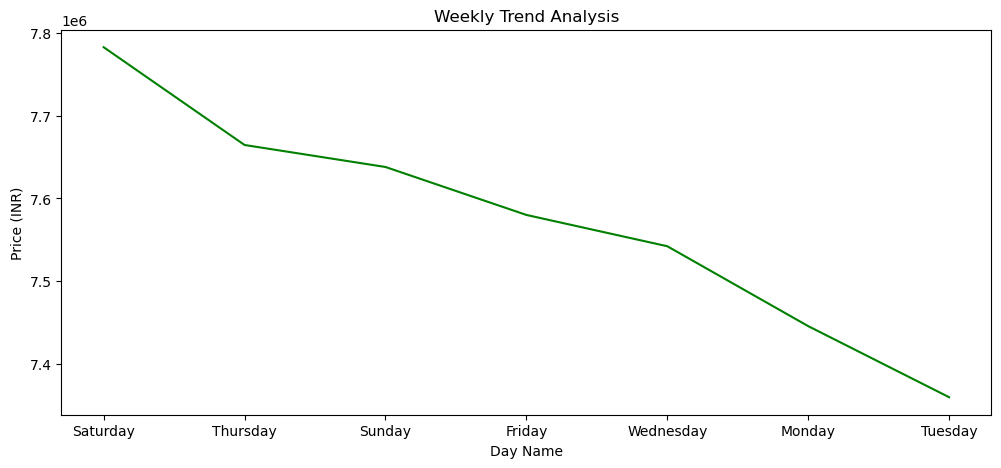

In [43]:
plt.figure(figsize=(12,5))

fig = sns.lineplot(Weekly_sales,
                  x = "Day Name",
                  y = "Price (INR)",
                  color="green")

plt.title('Weekly Trend Analysis')
plt.show()